# Portfolio Optimization Using Python

<a href="https://colab.research.google.com/github/bensonmacharia/ML/blob/main/portfolio_optimization_with_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project uses historical stock price data to build an optimal investment portfolio.

The goal is to:

- Read financial data using pandas
- Calculate daily returns
- Compute portfolio statistics
- Maximize the Sharpe Ratio using scipy.optimize
- Visualize the optimal portfolio performance

Libraries used:
- pandas
- numpy
- matplotlib
- scipy

### Import Libraries

In [99]:
# Data manipulation
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Date handling
import datetime as dt

# Mathematical functions

# Optimization library
import scipy.optimize as opt

# Financial data downloader
import yfinance as yf

### Download Financial Data

Instead of `util.get_data`, use yfinance because it is easier.

We download adjusted closing prices for several stocks.

Adjusted close prices are preferred because they account for:
- stock splits
- dividends
- corporate actions

In [100]:
# Define stock symbols
symbols = ['GOOG', 'AAPL', 'GLD', 'XOM', 'AMZN']

# Define date range
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=365*5)

# Download adjusted closing prices
prices = yf.download(
    symbols,
    start=start_date,
    end=end_date,
    auto_adjust=True
)['Close']

# Display first rows
prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GLD,GOOG,XOM
Date,,,,,
2021-05-17,123.081917,163.519501,174.699997,115.125336,52.097500
2021-05-18,121.697777,161.613998,175.039993,114.233650,50.623119
2021-05-19,121.541832,161.589996,175.160004,114.495499,49.408428
2021-05-20,124.095665,162.384003,175.960007,116.845200,49.291153
2021-05-21,122.263138,160.154007,176.039993,116.300179,49.358158


### Plot Stock Prices

This helps us understand how prices changed over time.

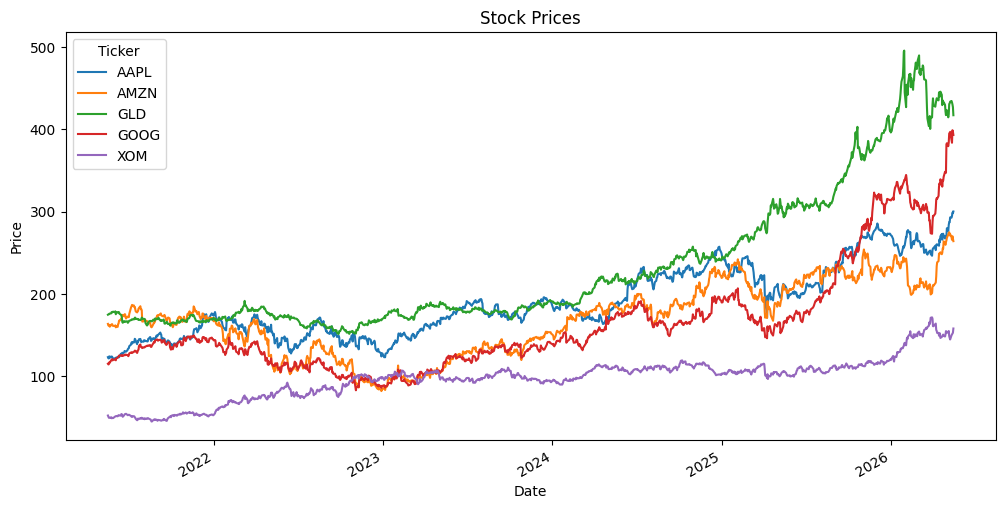

In [101]:
# Plot stock prices
prices.plot(figsize=(12,6))

plt.title("Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

### Normalize Prices

Stocks have different price ranges. Normalization allows us to compare them fairly by setting all starting prices to 1.

Using the normalization formula:

$$
P_{\text{normalized}} = \frac{P_t}{P_0}
$$

where:

- $P_{\text{normalized}} $ = normalized price
- $P_t $ = price at time t
- $P_0 $ = initial price (starting price)

In [102]:
# Normalize prices. This allows us to compare the relative performance of the stocks over time, regardless of their absolute price levels.
normalized_prices = prices / prices.iloc[0]
normalized_prices.head()

Ticker,AAPL,AMZN,GLD,GOOG,XOM
Date,,,,,
2021-05-17,1.000000,1.000000,1.000000,1.000000,1.000000
2021-05-18,0.988754,0.988347,1.001946,0.992255,0.971700
2021-05-19,0.987487,0.988200,1.002633,0.994529,0.948384
2021-05-20,1.008236,0.993056,1.007212,1.014939,0.946133
2021-05-21,0.993348,0.979418,1.007670,1.010205,0.947419


### Calculate Daily Returns

Daily return measures the percentage change in price from one day to the next.

In [103]:
# Calculate daily percentage returns
daily_returns = prices.pct_change()

# Remove missing values
daily_returns = daily_returns.dropna()

# Display returns
daily_returns.head()

Ticker,AAPL,AMZN,GLD,GOOG,XOM
Date,,,,,
2021-05-18,-0.011246,-0.011653,0.001946,-0.007745,-0.028300
2021-05-19,-0.001281,-0.000149,0.000686,0.002292,-0.023995
2021-05-20,0.021012,0.004914,0.004567,0.020522,-0.002374
2021-05-21,-0.014767,-0.013733,0.000455,-0.004664,0.001359
2021-05-24,0.013314,0.013084,0.001761,0.026255,0.011711


### Portfolio Calculations

Portfolio Return Formula

$$
R_p = \sum_{i=1}^{n} w_i R_i
$$

Where:
- $ w_i $ = portfolio weights
- $ R_i $ = asset returns

We create functions to calculate:
- portfolio return
- portfolio volatility
- Sharpe ratio

In [104]:
# Annualized mean returns
mean_returns = daily_returns.mean() * 252

# Annualized covariance matrix
cov_matrix = daily_returns.cov() * 252


def portfolio_performance(weights):
    """
    Calculate portfolio return and volatility.
    """

    # Portfolio return
    portfolio_return = np.sum(mean_returns * weights)

    # Portfolio volatility
    portfolio_volatility = np.sqrt(
        np.dot(weights.T,
               np.dot(cov_matrix, weights))
    )

    return portfolio_return, portfolio_volatility


def negative_sharpe_ratio(weights):
    """
    Negative Sharpe Ratio.
    
    We use negative because scipy minimizes functions,
    but we want to maximize the Sharpe Ratio.
    """

    portfolio_return, portfolio_volatility = portfolio_performance(weights)

    sharpe_ratio = portfolio_return / portfolio_volatility

    return -sharpe_ratio

### Optimization Constraints

We apply the following constraints:

1. Portfolio weights must sum to 1
2. No short selling allowed

In [105]:
# Number of assets
num_assets = len(symbols)

# Initial equal allocation
initial_weights = num_assets * [1 / num_assets]

# Constraint:
# Sum of all weights must equal 1
constraints = ({
    'type': 'eq',
    'fun': lambda weights: np.sum(weights) - 1
})

# Bounds:
# Each weight must stay between 0 and 1
bounds = tuple((0, 1) for asset in range(num_assets))

### Run Portfolio Optimization

We use scipy.optimize.minimize to find the portfolio with the maximum Sharpe Ratio.

In [106]:
# Run optimization
result = opt.minimize(
    negative_sharpe_ratio,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

# Optimal portfolio weights
optimal_weights = result.x

# Display results
for stock, weight in zip(symbols, optimal_weights):
    print(f"{stock}: {weight:.2%}")

GOOG: 7.58%
AAPL: 0.00%
GLD: 45.60%
XOM: 20.15%
AMZN: 26.67%


### Portfolio Statistics

In [107]:
# Calculate optimal portfolio statistics
portfolio_return, portfolio_volatility = portfolio_performance(optimal_weights)

# Sharpe Ratio
sharpe_ratio = portfolio_return / portfolio_volatility

print("Expected Annual Return:", round(portfolio_return, 4))
print("Annual Volatility:", round(portfolio_volatility, 4))
print("Sharpe Ratio:", round(sharpe_ratio, 4))

Expected Annual Return: 0.2319
Annual Volatility: 0.1464
Sharpe Ratio: 1.5844


### Visualize Optimal Allocation

Optimal Portfolio Allocation

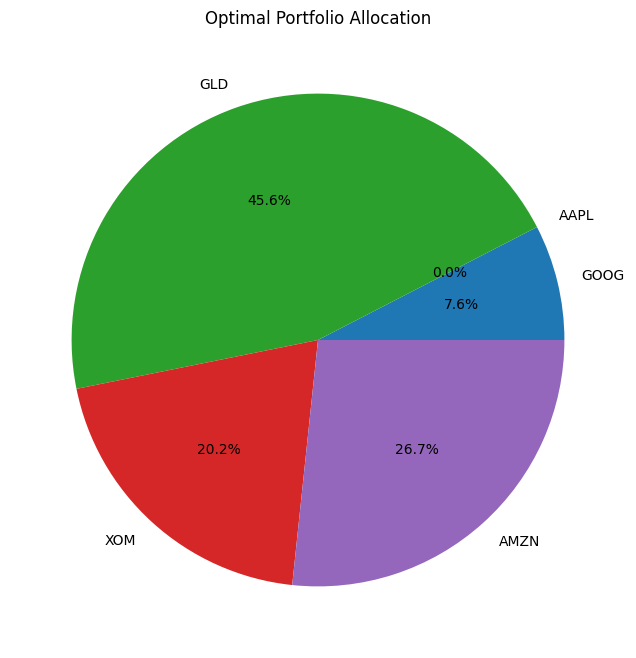

In [108]:
# Plot portfolio allocation
plt.figure(figsize=(8,8))

plt.pie(
    optimal_weights,
    labels=symbols,
    autopct='%1.1f%%'
)

plt.title("Optimal Portfolio Allocation")

plt.show()

### Plot Portfolio Value

Portfolio Performance Over Time

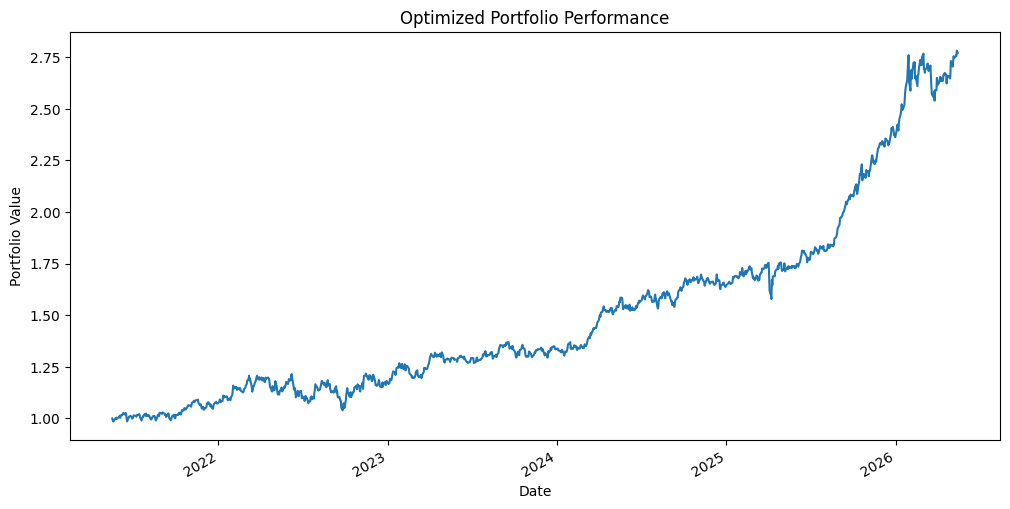

In [109]:
# Calculate weighted portfolio values
portfolio_values = (normalized_prices * optimal_weights).sum(axis=1)

# Plot portfolio performance
portfolio_values.plot(figsize=(12,6))

plt.title("Optimized Portfolio Performance")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.show()